# Problem Statement

## **Business Context**

"Visit with Us," a leading travel company, is revolutionizing the tourism industry by leveraging data-driven strategies to optimize operations and customer engagement. While introducing a new package offering, such as the Wellness Tourism Package, the company faces challenges in targeting the right customers efficiently. The manual approach to identifying potential customers is inconsistent, time-consuming, and prone to errors, leading to missed opportunities and suboptimal campaign performance.

To address these issues, the company aims to implement a scalable and automated system that integrates customer data, predicts potential buyers, and enhances decision-making for marketing strategies. By utilizing an MLOps pipeline, the company seeks to achieve seamless integration of data preprocessing, model development, deployment, and CI/CD practices for continuous improvement. This system will ensure efficient targeting of customers, timely updates to the predictive model, and adaptation to evolving customer behaviors, ultimately driving growth and customer satisfaction.


## **Objective**

As an MLOps Engineer at "Visit with Us," your responsibility is to design and deploy an MLOps pipeline on GitHub to automate the end-to-end workflow for predicting customer purchases. The primary objective is to build a model that predicts whether a customer will purchase the newly introduced Wellness Tourism Package before contacting them. The pipeline will include data cleaning, preprocessing, transformation, model building, training, evaluation, and deployment, ensuring consistent performance and scalability. By leveraging GitHub Actions for CI/CD integration, the system will enable automated updates, streamline model deployment, and improve operational efficiency. This robust predictive solution will empower policymakers to make data-driven decisions, enhance marketing strategies, and effectively target potential customers, thereby driving customer acquisition and business growth.

## **Data Description**

The dataset contains customer and interaction data that serve as key attributes for predicting the likelihood of purchasing the Wellness Tourism Package. The detailed attributes are:

**Customer Details**
- **CustomerID:** Unique identifier for each customer.
- **ProdTaken:** Target variable indicating whether the customer has purchased a package (0: No, 1: Yes).
- **Age:** Age of the customer.
- **TypeofContact:** The method by which the customer was contacted (Company Invited or Self Inquiry).
- **CityTier:** The city category based on development, population, and living standards (Tier 1 > Tier 2 > Tier 3).
- **Occupation:** Customer's occupation (e.g., Salaried, Freelancer).
- **Gender:** Gender of the customer (Male, Female).
- **NumberOfPersonVisiting:** Total number of people accompanying the customer on the trip.
- **PreferredPropertyStar:** Preferred hotel rating by the customer.
- **MaritalStatus:** Marital status of the customer (Single, Married, Divorced).
- **NumberOfTrips:** Average number of trips the customer takes annually.
- **Passport:** Whether the customer holds a valid passport (0: No, 1: Yes).
- **OwnCar:** Whether the customer owns a car (0: No, 1: Yes).
- **NumberOfChildrenVisiting:** Number of children below age 5 accompanying the customer.
- **Designation:** Customer's designation in their current organization.
- **MonthlyIncome:** Gross monthly income of the customer.

**Customer Interaction Data**
- **PitchSatisfactionScore:** Score indicating the customer's satisfaction with the sales pitch.
- **ProductPitched:** The type of product pitched to the customer.
- **NumberOfFollowups:** Total number of follow-ups by the salesperson after the sales pitch.-
- **DurationOfPitch:** Duration of the sales pitch delivered to the customer.


# Model Building

In [1]:
# Create a master folder to keep all files created when executing the below code cells
import os
os.makedirs("tourism_project", exist_ok=True)

In [2]:
# Create a folder for storing the model building files
os.makedirs("tourism_project/model_building", exist_ok=True)

1. **Imports Libraries**: It brings in the necessary tools for working with the Hugging Face Hub.

2. **Sets Up Repository Information**: It defines where the dataset will be stored, including a placeholder for the user ID and dataset name.

3. **Initializes the API Client**: It sets up a connection to the Hugging Face Hub using an authentication token stored in your environment.

4. **Checks for Existing Repository**: It looks for an existing dataset repository. If it finds one, it informs you.

5. **Creates a New Repository**: If the repository doesn't exist, it creates a new one and lets you know it has been created.

6. **Uploads Data**: Finally, it uploads a folder of dataset files to the repository.

Overall, this code is a tool for managing datasets on the Hugging Face platform, allowing you to check for, create, and upload to a repository easily.

## Data Registration

In [6]:
%%writefile tourism_project/model_building/data_register.py
from huggingface_hub import HfApi, create_repo
from huggingface_hub.utils import RepositoryNotFoundError
import os

DATASET_REPO_ID = "BharatBoddu/tourism-purchase-dataset"
DATASET_REPO_TYPE = "dataset"
LOCAL_DATA_PATH = "tourism_project/data"

api = HfApi(token=os.getenv("HF_TOKEN"))

try:
    api.repo_info(repo_id=DATASET_REPO_ID, repo_type=DATASET_REPO_TYPE)
    print(f"Dataset repo '{DATASET_REPO_ID}' already exists.")
except RepositoryNotFoundError:
    create_repo(repo_id=DATASET_REPO_ID, repo_type=DATASET_REPO_TYPE, private=False)
    print(f"Created dataset repo '{DATASET_REPO_ID}'.")

api.upload_folder(
    folder_path=LOCAL_DATA_PATH,
    repo_id=DATASET_REPO_ID,
    repo_type=DATASET_REPO_TYPE,
)
print("Data uploaded to Hugging Face Dataset Hub.")

Overwriting tourism_project/model_building/data_register.py


Once the **data** folder created after executing the above cell, please upload the **tourism.csv** in to the folder

## Data Preparation

1. **Imports Necessary Libraries**:

2. **Dataset Loading**:
   - The script defines a path to a dataset stored on Hugging Face and reads it into a Pandas DataFrame.

3. **Data Preparation**:
   - The code creates matrices for predictors (features) and the target variable.
   - It splits the dataset into training and testing sets, reserving 20% of the data for testing. This is done to evaluate the model's performance later.

4. **Saving Prepared Data**:
   - After splitting, the script saves the training and testing datasets (features and target) as CSV files.

5. **Uploading Files**:
   - Finally, it uploads these CSV files back to the Hugging Face Hub, ensuring that they are properly stored in the specified repository.

In [22]:
%%writefile tourism_project/model_building/prep.py
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from huggingface_hub import HfApi

DATASET_REPO_ID = "BharatBoddu/tourism-purchase-dataset"
DATASET_REPO_TYPE = "dataset"
INPUT_DATA_PATH = f"hf://datasets/{DATASET_REPO_ID}/tourism.csv"

api = HfApi(token=os.getenv("HF_TOKEN"))

# Load dataset from Hugging Face
raw_df = pd.read_csv(INPUT_DATA_PATH)
print("Dataset loaded from Hugging Face.")

# Basic cleaning
clean_df = raw_df.copy()
if "CustomerID" in clean_df.columns:
    clean_df = clean_df.drop(columns=["CustomerID","Unnamed: 0"])

for col in clean_df.columns:
    if clean_df[col].dtype == "object":
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode().iloc[0])
    else:
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Split into train and test sets
target_col = "ProdTaken"
X = clean_df.drop(columns=[target_col])
y = clean_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Save locally
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# Upload split data back to Hugging Face
for file_name in ["X_train.csv", "X_test.csv", "y_train.csv", "y_test.csv"]:
    api.upload_file(
        path_or_fileobj=file_name,
        path_in_repo=file_name,
        repo_id=DATASET_REPO_ID,
        repo_type=DATASET_REPO_TYPE,
    )

print("Prepared train/test files uploaded to Hugging Face Dataset Hub.")

Overwriting tourism_project/model_building/prep.py


## Model Training and Registration with Experimentation Tracking

1. **Imports Necessary Libraries:** Essential libraries for data handling, preprocessing, model training, evaluation, experiment tracking, and interaction with the Hugging Face Hub are imported.

2. **Dataset Configuration:** Dataset and model repository IDs are defined for accessing data and storing the trained model on Hugging Face.

3. **Data Loading:** Training and testing datasets (features and target labels) are loaded directly from the Hugging Face Dataset Hub using pandas.

4. **Feature Identification:** Numerical and categorical features are automatically identified from the dataset based on their data types.

5. **Preprocessing Pipelines:** Separate preprocessing pipelines are created:
   * Numerical features are imputed with median values and scaled using StandardScaler.
   * Categorical features are imputed with the most frequent values and encoded using OneHotEncoder.

6. **Column Transformer Setup:** A ColumnTransformer combines numerical and categorical preprocessing pipelines into a single preprocessing workflow.

7. **Model Pipeline Definition:** A complete machine learning pipeline is built by integrating the preprocessing steps with a RandomForestClassifier configured with balanced class weights.

8. **Hyperparameter Grid Definition:** A parameter grid is specified for tuning important Random Forest hyperparameters such as number of estimators, tree depth, and minimum split/leaf sizes.

9. **MLflow Experiment Tracking:** MLflow is configured with a tracking server and experiment name to record training runs, parameters, and evaluation metrics.

10. **Hyperparameter Tuning with Grid Search:** GridSearchCV is used with 3-fold cross-validation to identify the best parameter combination based on the F1-score.

11. **Logging Parameter Combinations:** Each parameter combination tested during grid search is logged as a nested MLflow run along with its mean cross-validation F1-score.

12. **Model Evaluation:** The best model from grid search is selected and evaluated on the test dataset using metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

13. **Metric and Parameter Logging:** The best hyperparameters and evaluation metrics are logged into MLflow for experiment comparison and reproducibility.

14. **Model Saving:** The trained best-performing model is saved locally as a .joblib file.

15. **Artifact Logging in MLflow:** The saved model file is logged as an MLflow artifact for centralized experiment storage.

16. **Hugging Face Model Repository Handling:** The script checks whether the Hugging Face model repository exists. If it does not exist, a new repository is created automatically.

17. **Uploading Model to Hugging Face:** The trained model file is uploaded to the Hugging Face Model Hub, making it accessible for deployment and reuse.

18. **Completion Message:** A confirmation message is displayed after the model has been successfully uploaded to Hugging Face.

In [32]:
%%writefile tourism_project/model_building/train.py
import os
import joblib
import pandas as pd
import mlflow
from huggingface_hub import HfApi, create_repo
from huggingface_hub.utils import RepositoryNotFoundError
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATASET_REPO_ID = "BharatBoddu/tourism-purchase-dataset"
MODEL_REPO_ID = "BharatBoddu/tourism-purchase-model"

X_train = pd.read_csv(f"hf://datasets/{DATASET_REPO_ID}/X_train.csv")
X_test = pd.read_csv(f"hf://datasets/{DATASET_REPO_ID}/X_test.csv")
y_train = pd.read_csv(f"hf://datasets/{DATASET_REPO_ID}/y_train.csv").values.ravel()
y_test = pd.read_csv(f"hf://datasets/{DATASET_REPO_ID}/y_test.csv").values.ravel()

print("Training columns:")
print(X_train.columns.tolist())

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced")),
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("tourism_mlops_experiment")

with mlflow.start_run():
    grid_search = GridSearchCV(
        estimator=model_pipeline,
        param_grid=param_grid,
        cv=3,
        n_jobs=-1,
        scoring="f1",
    )
    grid_search.fit(X_train, y_train)

    # Log all tuned parameter combinations
    results = grid_search.cv_results_
    for i in range(len(results["params"])):
        with mlflow.start_run(nested=True):
            mlflow.log_params(results["params"][i])
            mlflow.log_metric("mean_cv_f1", float(results["mean_test_score"][i]))

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }

    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metrics(metrics)

    model_file = "best_tourism_model.joblib"
    joblib.dump(best_model, model_file)
    mlflow.log_artifact(model_file, artifact_path="model")

api = HfApi(token=os.getenv("HF_TOKEN"))
try:
    api.repo_info(repo_id=MODEL_REPO_ID, repo_type="model")
except RepositoryNotFoundError:
    create_repo(repo_id=MODEL_REPO_ID, repo_type="model", private=False)
print(best_model.feature_names_in_)
api.upload_file(
    path_or_fileobj="best_tourism_model.joblib",
    path_in_repo="best_tourism_model.joblib",
    repo_id=MODEL_REPO_ID,
    repo_type="model",
)

print("Best model uploaded to Hugging Face Model Hub.")

Overwriting tourism_project/model_building/train.py


# Deployment

## Dockerfile

In [33]:
os.makedirs("tourism_project/deployment", exist_ok=True)

1. **Base Image**:
   - A minimal Docker image with Python 3.9 installed is specified as the starting point. This ensures that the necessary Python environment is available for the application.

2. **Working Directory**:
   - The working directory inside the container is set to `/app`. This is where all subsequent actions will take place.

3. **Copying Files**:
   - All files from the current directory on the host machine are copied into the container's `/app` directory. This includes the application code and other necessary files.

4. **Installing Dependencies**:
   - The command installs Python packages listed in a `requirements.txt` file. This file typically contains all the dependencies needed for the application to run properly.

5. **Creating a User**:
   - A new user is created inside the container with a specific user ID (1000). This is a best practice for security, as applications should not run as the root user.

6. **Setting Environment Variables**:
   - Environment variables are set, including the home directory for the new user and the PATH variable to include the user's local binary directory.

7. **Changing Working Directory**:
   - The working directory is changed to the user's home directory where the application files are located.

8. **Copying Files with Ownership**:
   - The application files are copied into the user's home directory with the appropriate ownership, ensuring that the user has the necessary permissions.

9. **Command to Run the Application**:
   - The command defines how to run the Streamlit application when the container starts. It specifies the script to execute (`app.py`) and sets the server to listen on port 8501, making it accessible externally. XSRF protection is also disabled for the server.

In [34]:
%%writefile tourism_project/deployment/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

RUN useradd -m -u 1000 user
USER user
ENV HOME=/home/user \
	PATH=/home/user/.local/bin:$PATH

WORKDIR $HOME/app

COPY --chown=user . $HOME/app

# Define the command to run the Streamlit app on port "8501" and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Overwriting tourism_project/deployment/Dockerfile


## Streamlit App

This application provides an interactive tool for machine failure prediction which predicts whether the machine will gonna fail or not over a period of time. It downloads a pre-trained machine learning model, collects user inputs, makes predictions, and displays results in a user-friendly interface. To use the application, ensure that the placeholder for the Hugging Face user ID is replaced with a valid one.

Please ensure that the web app script is named `app.py`.

In [35]:
%%writefile tourism_project/deployment/app.py
import joblib
import pandas as pd
import streamlit as st
from huggingface_hub import hf_hub_download

MODEL_REPO_ID = "BharatBoddu/tourism-purchase-model"
MODEL_FILE = "best_tourism_model.joblib"

model_path = hf_hub_download(repo_id=MODEL_REPO_ID, filename=MODEL_FILE)
model = joblib.load(model_path)

st.title("Wellness Tourism Package Purchase Prediction")
st.write("Predict whether a customer is likely to purchase the new package.")

# Collect user inputs
input_data = {
    "Age": st.number_input("Age", min_value=18, max_value=90, value=35),
    "TypeofContact": st.selectbox("Type of Contact", ["Company Invited", "Self Enquiry", "Self Inquiry"]),
    "CityTier": st.number_input("City Tier", min_value=1, max_value=3, value=2),
    "Occupation": st.selectbox("Occupation", ["Salaried", "Small Business", "Large Business", "Free Lancer"]),
    "Gender": st.selectbox("Gender", ["Male", "Female"]),
    "NumberOfPersonVisiting": st.number_input("Number Of Persons Visiting", min_value=1, max_value=10, value=2),
    "PreferredPropertyStar": st.number_input("Preferred Property Star", min_value=1, max_value=5, value=3),
    "MaritalStatus": st.selectbox("Marital Status", ["Single", "Married", "Divorced"]),
    "NumberOfTrips": st.number_input("Number Of Trips Per Year", min_value=0, max_value=20, value=2),
    "Passport": st.selectbox("Has Passport", [0, 1]),
    "OwnCar": st.selectbox("Owns Car", [0, 1]),
    "NumberOfChildrenVisiting": st.number_input("Number Of Children Visiting", min_value=0, max_value=6, value=0),
    "Designation": st.selectbox("Designation", ["AVP", "VP", "Manager", "Senior Manager", "Executive"]),
    "MonthlyIncome": st.number_input("Monthly Income", min_value=1000, max_value=500000, value=30000),
    "PitchSatisfactionScore": st.slider("Pitch Satisfaction Score", min_value=1, max_value=5, value=3),
    "ProductPitched": st.selectbox("Product Pitched", ["Basic", "Standard", "Deluxe", "Super Deluxe", "King"]),
    "NumberOfFollowups": st.number_input("Number Of Followups", min_value=0, max_value=10, value=2),
    "DurationOfPitch": st.number_input("Duration Of Pitch", min_value=5, max_value=300, value=30),
}

if st.button("Predict"):
    input_df = pd.DataFrame([input_data])
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    if prediction == 1:
        st.success(f"Likely to purchase (probability: {probability:.2%})")
    else:
        st.warning(f"Unlikely to purchase (probability: {probability:.2%})")

Overwriting tourism_project/deployment/app.py


## Dependency Handling

Please ensure that the dependency handling file is named `requirements.txt`.

In [36]:
%%writefile tourism_project/deployment/requirements.txt
pandas==2.2.2
scikit-learn==1.6.0
streamlit==1.43.2
huggingface_hub==0.32.6
joblib==1.5.1

Overwriting tourism_project/deployment/requirements.txt


# Hosting

1. **Imports**:
   - The `HfApi` class is imported from the `huggingface_hub` library to facilitate communication with the Hugging Face Hub.
   - The `os` module is imported to access environment variables.

2. **API Initialization**:
   - An instance of the `HfApi` class is created using an authentication token retrieved from the environment variable `HF_TOKEN`. This token is necessary for authenticating actions performed on the Hugging Face Hub.

3. **Upload Command**:
   - The `upload_folder` method is called to upload all files from the specified local folder (`mlops/deployment`) to a designated repository on Hugging Face.
   - **Parameters**:
     - `folder_path`: Specifies the local directory containing the files to be uploaded.
     - `repo_id`: Indicates the target repository on Hugging Face, which should include the user's ID and the repository name.
     - `repo_type`: Identifies the type of repository being used (in this case, it’s marked as a "space").
     - `path_in_repo`: This optional parameter defines a subfolder path within the repository where files should be placed. It’s left empty to upload files directly to the root of the specified repo.

In [15]:
os.makedirs("tourism_project/hosting", exist_ok=True)

In [37]:
%%writefile tourism_project/hosting/hosting.py
from huggingface_hub import HfApi
import os

SPACE_REPO_ID = "BharatBoddu/tourism-purchase-prediction-app"

api = HfApi(token=os.getenv("HF_TOKEN"))
api.upload_folder(
    folder_path="tourism_project/deployment",
    repo_id=SPACE_REPO_ID,
    repo_type="space",
    path_in_repo="",
)
print("Deployment files pushed to Hugging Face Space.")

Overwriting tourism_project/hosting/hosting.py


# MLOps Pipeline with Github Actions Workflow

**Note:**

1. Before running the file below, make sure to add the HF_TOKEN to your GitHub secrets to enable authentication between GitHub and Hugging Face.

* A YAML file is a simple, human-readable file used to store configuration settings.
* YAML stands for Yet Another Markup Language or YAML Ain't Markup Language (a recursive acronym).
* It uses indentation (spaces) to show structure, like folders inside folders.
* Each line contains a key and a value, making it easy to organize data.
* YAML is often used in automation tools, cloud setups, and app settings.

Here's the YAML file we'd need for our use case.

```
name: Tourism Project Pipeline

on:
  push:
    branches:
      - main

jobs:
  register-dataset:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r tourism_project/requirements.txt
      - name: Upload Dataset to Hugging Face Hub
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/model_building/data_register.py

  data-prep:
    needs: register-dataset
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r tourism_project/requirements.txt
      - name: Run Data Preparation
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/model_building/prep.py

  model-training:
    needs: data-prep
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r tourism_project/requirements.txt
      - name: Start MLflow Server
        run: |
          nohup mlflow ui --host 0.0.0.0 --port 5000 &
          sleep 5
      - name: Train, Track, and Register Model
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/model_building/train.py

  deploy-hosting:
    needs: [register-dataset, data-prep, model-training]
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r tourism_project/requirements.txt
      - name: Push Deployment Files to Hugging Face Space
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python tourism_project/hosting/hosting.py
```

**Note:** To use this YAML file for our use case, we need to

1. Go to the GitHub repository for the project
2. Create a folder named ***.github/workflows/***
3. In the above folder, create a file named ***pipeline.yml***
4. Copy and paste the above content for the YAML file into the ***pipeline.yml*** file

## Requirements file for the Github Actions Workflow

In [17]:
%%writefile tourism_project/requirements.txt
huggingface_hub==0.32.6
pandas==2.2.2
scikit-learn==1.6.0
joblib==1.5.1
mlflow==3.0.1
streamlit==1.43.2

Writing tourism_project/requirements.txt


## Github Authentication and Push Files

* Before moving forward, we need to generate a secret token to push files directly from Colab to the GitHub repository.
* Please follow the below instructions to create the GitHub token:
    - Open your GitHub profile.
    - Click on ***Settings***.
    - Go to ***Developer Settings***.
    - Expand the ***Personal access tokens*** section and select ***Tokens (classic)***.
    - Click ***Generate new token***, then choose ***Generate new token (classic)***.
    - Add a note and select all required scopes.
    - Click ***Generate token***.
    - Copy the generated token and store it safely in a notepad.

In [38]:
# Install Git
!apt-get install git

# Set your Git identity (replace with your details)
!git config --global user.email "kumar.boddu20@gmail.com"
!git config --global user.name "BharatBoddu"

# Clone your GitHub repository
!git clone https://github.com/BharatBoddu/tourism-mlops-project.git

# Move your folder to the repository directory
!mv /content/tourism_project/ /content/tourism-mlops-project

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
Cloning into 'tourism-mlops-project'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 28 (delta 1), reused 28 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 95.71 KiB | 1.35 MiB/s, done.
Resolving deltas: 100% (1/1), done.
mv: cannot move '/content/tourism_project/' to '/content/tourism-mlops-project/tourism_project': Directory not empty


In [39]:
# Change directory to the cloned repository
%cd tourism-mlops-project/

# Add the new folder to Git
!git add .

# Commit the changes
!git commit -m "first commit"

# Push to GitHub (you'll need your GitHub credentials; use a personal access token if 2FA enabled)
!git push https://BharatBoddu:<--------GitHub Token--------->@github.com/BharatBoddu/tourism-mlops-project.git

/content/tourism-mlops-project/tourism-mlops-project
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
/bin/bash: line 1: --------GitHub: No such file or directory


# Output Evaluation

- GitHub (link to repository, screenshot of folder structure and executed workflow)

In [20]:
# Replace these placeholders after deployment
GITHUB_REPO_LINK = "https://github.com/BharatBoddu/tourism-mlops-project"

print("GitHub Output Evaluation Checklist")
print("Repository Link:", GITHUB_REPO_LINK)
print("1. Add screenshot of tourism_project folder structure")
print("2. Add screenshot of successful GitHub Actions workflow run")

GitHub Output Evaluation Checklist
Repository Link: https://github.com/BharatBoddu/tourism-mlops-project
1. Add screenshot of tourism_project folder structure
2. Add screenshot of successful GitHub Actions workflow run


**Github tourism_project folder structure**

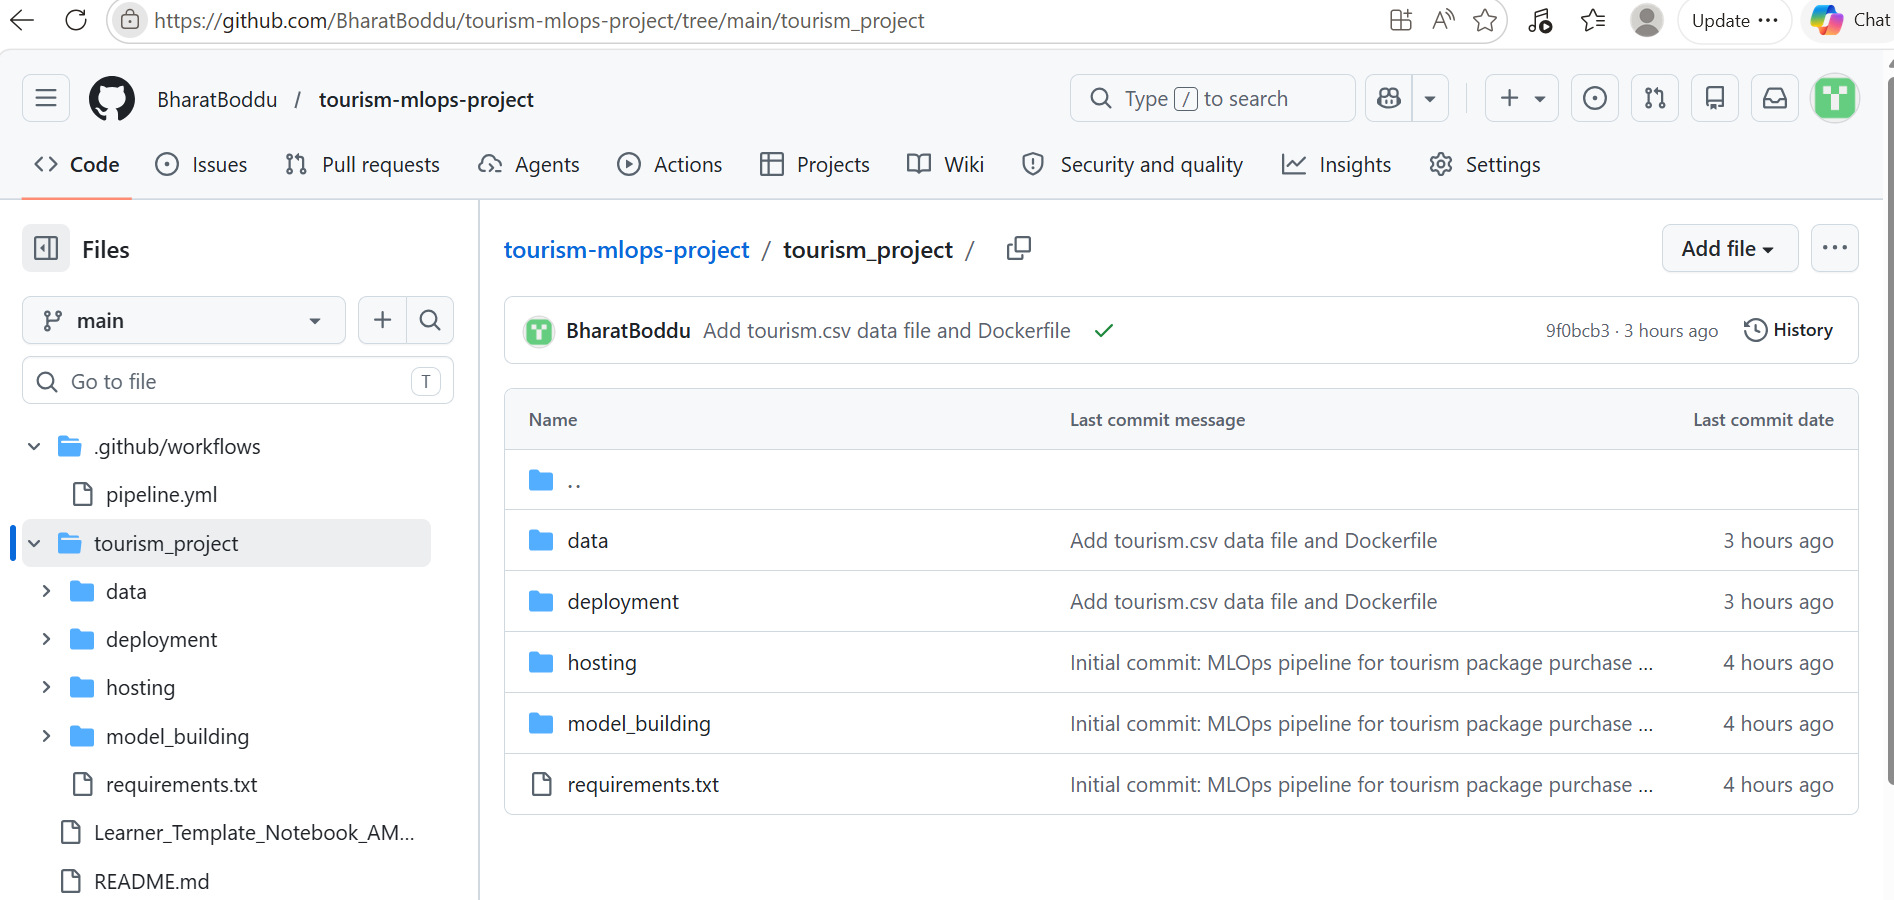

**Github Actions workflow**

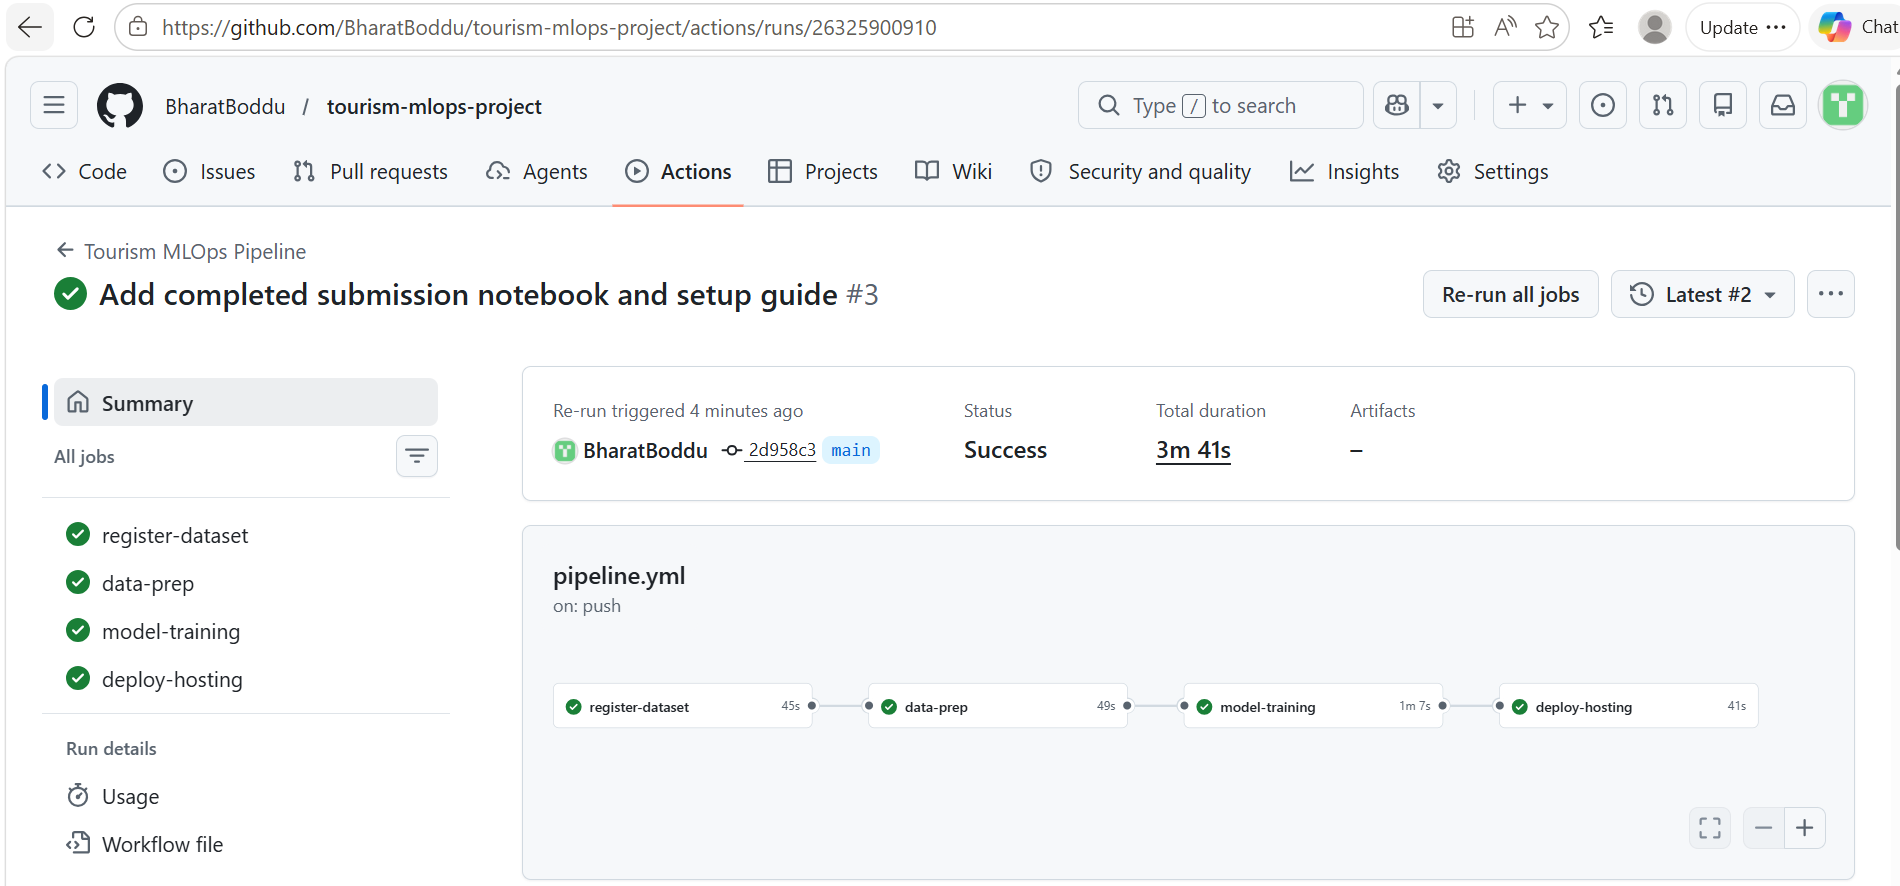

- Streamlit on Hugging Face (link to HF space, screenshot of Streamlit app)

In [21]:
# Replace this placeholder after hosting is complete
HF_SPACE_LINK = "https://huggingface.co/spaces/BharatBoddu/tourism-purchase-prediction-app"

print("Streamlit on Hugging Face Checklist")
print("Space Link:", HF_SPACE_LINK)
print("1. Open the public Space URL and validate predictions")
print("2. Add screenshot of the Streamlit app in your submission")

Streamlit on Hugging Face Checklist
Space Link: https://huggingface.co/spaces/BharatBoddu/tourism-purchase-prediction-app
1. Open the public Space URL and validate predictions
2. Add screenshot of the Streamlit app in your submission


<font size=6 color="navyblue">Power Ahead!</font>
___